# STFT Time-Frequency Analysis of a Chirp Signal

This notebook studies a linear chirp signal with the Short-Time Fourier Transform (STFT), compares spectral windows, and analyzes time-frequency resolution trade-offs.

## 1. Introduction
A chirp is a non-stationary signal whose frequency changes over time. STFT is used to localize spectral content in both time and frequency.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parents[0]
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from signal_generation import generate_chirp
from stft_analysis import compute_stft, quantify_resolution_blur

FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Signal Generation

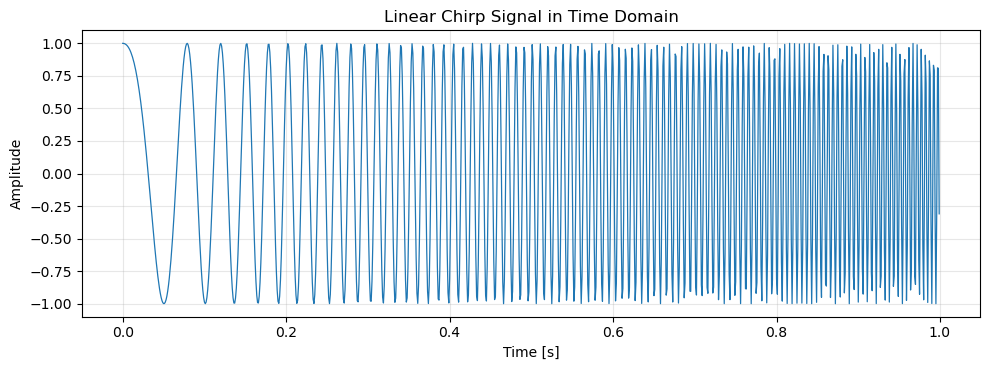

In [2]:
fs = 1000
t, x = generate_chirp(fs=fs, f0=5.0, f1=200.0, duration=1.0)

plt.figure(figsize=(10, 3.8))
plt.plot(t, x, color='tab:blue', linewidth=0.9)
plt.title('Linear Chirp Signal in Time Domain')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'chirp_signal.png', dpi=180)
plt.show()

## 3. STFT Method
For each frame centered at $\tau_m$, STFT computes

$$
Z_{xx}(f_k, \tau_m) = \sum_n x[n]w[n-mR]e^{-j2\pi kn/N}.
$$

Here, $f_k$ are frequency bins, $\tau_m$ are frame times, and $Z_{xx}$ is the complex STFT output.

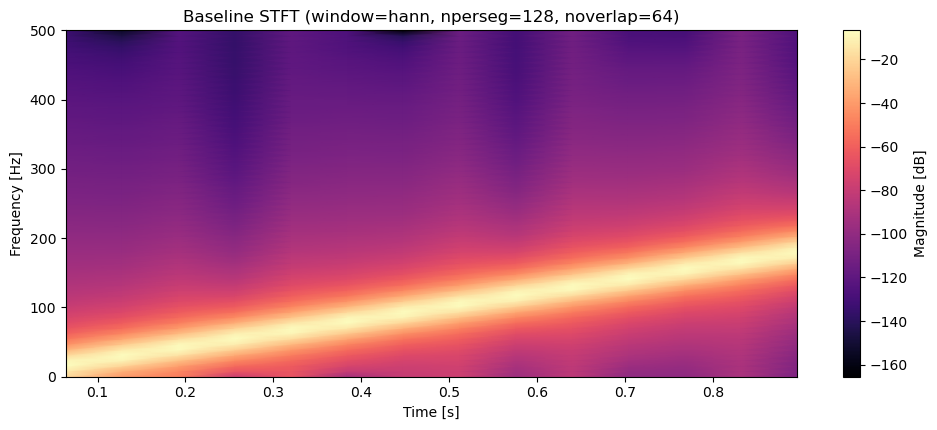

In [3]:
def show_spectrogram(f, tau, zxx, title, save_name):
    # |Zxx| = sqrt(Re(Zxx)^2 + Im(Zxx)^2), then converted to dB for display.
    mag = np.abs(zxx)
    mag_db = 20.0 * np.log10(mag + 1e-12)

    plt.figure(figsize=(10, 4.4))
    mesh = plt.pcolormesh(tau, f, mag_db, shading='gouraud', cmap='magma')
    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel('Frequency [Hz]')
    cbar = plt.colorbar(mesh)
    cbar.set_label('Magnitude [dB]')
    plt.tight_layout()
    plt.savefig(FIG_DIR / save_name, dpi=180)
    plt.show()

f, tau, zxx = compute_stft(x, fs, window='hann', nperseg=128, noverlap=64)
show_spectrogram(
    f, tau, zxx,
    'Baseline STFT (window=hann, nperseg=128, noverlap=64)',
    'stft_hann_baseline.png'
)

## 4. Window Comparison
Compare Hann, Hamming, Blackman, and Gaussian with identical segment length and overlap.

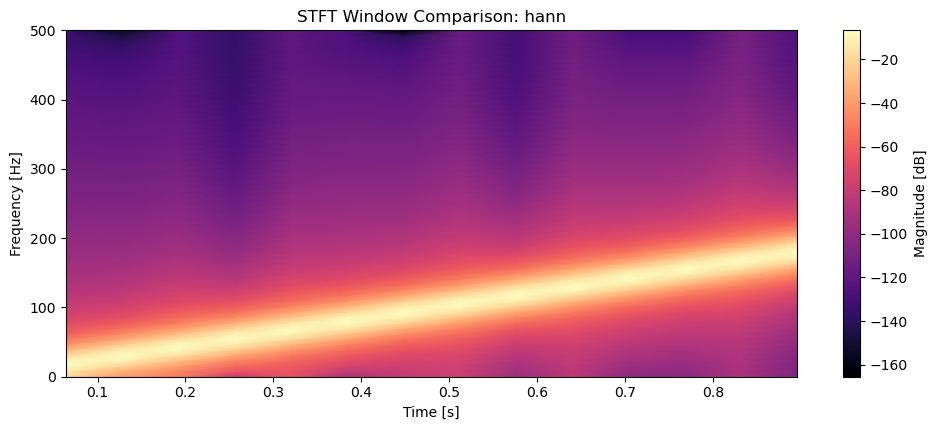

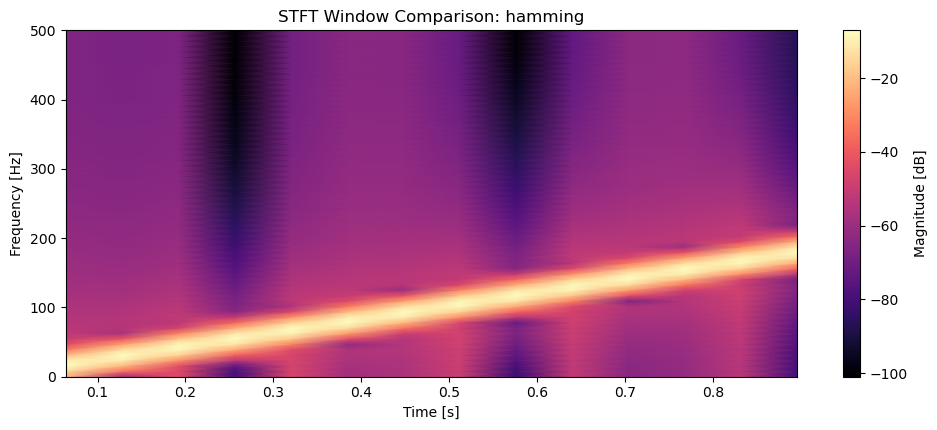

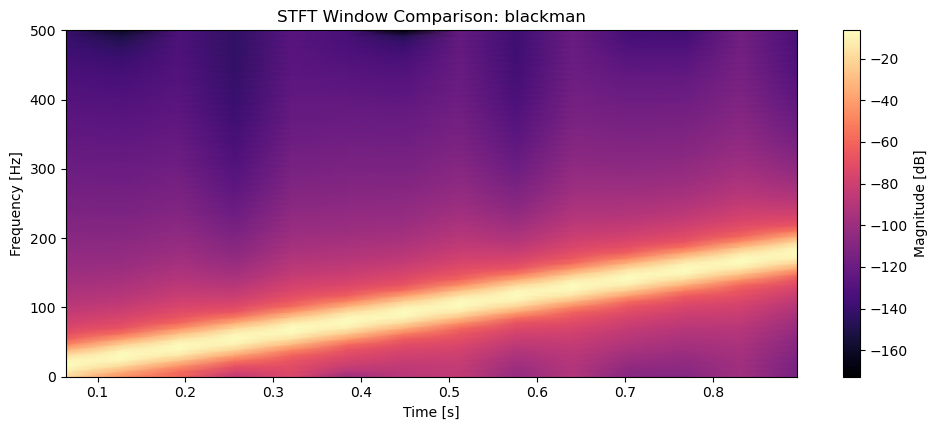

In [ ]:
window_specs = [
    ('hann', 'hann'),
    ('hamming', 'hamming'),
    ('blackman', 'blackman'),
    ('gaussian', ('gaussian', 16.0)),
]

for win_name, win_spec in window_specs:
    f, tau, zxx = compute_stft(x, fs, window=win_spec, nperseg=128, noverlap=64)
    show_spectrogram(
        f, tau, zxx,
        f'STFT Window Comparison: {win_name}',
        f'stft_{win_name}.png'
We quantify blurriness using energy-weighted spread (\(2\sigma\)) widths:
- Frequency blur: median ridge thickness in Hz
- Time blur: median temporal spread in seconds at selected frequency slices
Larger width means blurrier representation along that axis.
markdown
#VSC-b03fa720
markdown
## 5. Resolution Analysis
Smaller windows improve time localization but blur frequency, while larger windows improve frequency localization but blur time.
code
#VSC-3cbd29d5
python
for nperseg in [64, 128, 256]:
    noverlap = nperseg // 2
    f, tau, zxx = compute_stft(x, fs, window='hann', nperseg=nperseg, noverlap=noverlap)
    show_spectrogram(
        f, tau, zxx,
        f'Resolution Study: nperseg={nperseg}, noverlap={noverlap}',
        f'stft_nperseg_{nperseg}.png'
    )
markdown
#VSC-b6fbd09b
markdown
## 6. Quantitative Blur Metrics
We quantify blurriness using half-power (\(-3\) dB) widths:
- Frequency blur: median ridge thickness in Hz
- Time blur: median temporal spread in seconds at selected frequency slices
code
#VSC-92f9af50
python
rows = []
for nperseg in [64, 128, 256]:
    noverlap = nperseg // 2
    f, tau, zxx = compute_stft(x, fs, window='hann', nperseg=nperseg, noverlap=noverlap)
    metrics = quantify_resolution_blur(f, tau, zxx, f0=5.0, f1=200.0, duration=1.0)
    rows.append((nperseg, noverlap, metrics['freq_blur_hz'], metrics['time_blur_s'], metrics['freq_blur_bins'], metrics['time_blur_frames']))

print('nperseg | noverlap | freq_blur_hz | time_blur_s | freq_blur_bins | time_blur_frames')
for r in rows:
    print(f'{r[0]:7d} | {r[1]:8d} | {r[2]:12.3f} | {r[3]:11.4f} | {r[4]:14.3f} | {r[5]:16.3f}')
markdown
#VSC-c9a66a24
markdown
## 7. Conclusion
STFT effectively captures chirp frequency evolution over time. Window shape affects leakage behavior, and segment length controls the time-frequency resolution trade-off.